In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("data/food_orders_new_delhi.csv")

df.head()

,Order ID,Customer ID,Restaurant ID,Order Date and Time,Delivery Date and Time,Order Value,Delivery Fee,Payment Method,Discounts and Offers,Commission Fee,Payment Processing Fee,Refunds/Chargebacks
0,1,C8270,R2924,2024-02-01 01:11:52,2024-02-01 02:39:52,1914,0,Credit Card,5% on App,150,47,0
1,2,C1860,R2054,2024-02-02 22:11:04,2024-02-02 22:46:04,986,40,Digital Wallet,10%,198,23,0
2,3,C6390,R2870,2024-01-31 05:54:35,2024-01-31 06:52:35,937,30,Cash on Delivery,15% New User,195,45,0
3,4,C6191,R2642,2024-01-16 22:52:49,2024-01-16 23:38:49,1463,50,Cash on Delivery,NaN,146,27,0
4,5,C6734,R2799,2024-01-29 01:19:30,2024-01-29 02:48:30,1992,30,Cash on Delivery,50 off Promo,130,50,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Order ID                1000 non-null   int64 
 1   Customer ID             1000 non-null   object
 2   Restaurant ID           1000 non-null   object
 3   Order Date and Time     1000 non-null   object
 4   Delivery Date and Time  1000 non-null   object
 5   Order Value             1000 non-null   int64 
 6   Delivery Fee            1000 non-null   int64 
 7   Payment Method          1000 non-null   object
 8   Discounts and Offers    815 non-null    object
 9   Commission Fee          1000 non-null   int64 
 10  Payment Processing Fee  1000 non-null   int64 
 11  Refunds/Chargebacks     1000 non-null   int64 
dtypes: int64(6), object(6)
memory usage: 93.9+ KB


In [5]:
df.describe()

,Order ID,Order Value,Delivery Fee,Commission Fee,Payment Processing Fee,Refunds/Chargebacks
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,1053.969000,28.620000,126.99000,29.832000,28.300000
std,288.819436,530.975339,16.958278,43.06405,11.627165,49.614228
min,1.000000,104.000000,0.000000,50.00000,10.000000,0.000000
25%,250.750000,597.750000,20.000000,90.00000,20.000000,0.000000
50%,500.500000,1038.500000,30.000000,127.00000,30.000000,0.000000
75%,750.250000,1494.000000,40.000000,164.00000,40.000000,50.000000
max,1000.000000,1995.000000,50.000000,200.00000,50.000000,150.000000


In [6]:
# Data Cleaning
# Convert order time columns from string to datetime format
df["Order Date and Time"] = pd.to_datetime(df["Order Date and Time"])
df["Delivery Date and Time"] = pd.to_datetime(df["Delivery Date and Time"])

In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Order ID                1000 non-null   int64         
 1   Customer ID             1000 non-null   object        
 2   Restaurant ID           1000 non-null   object        
 3   Order Date and Time     1000 non-null   datetime64[ns]
 4   Delivery Date and Time  1000 non-null   datetime64[ns]
 5   Order Value             1000 non-null   int64         
 6   Delivery Fee            1000 non-null   int64         
 7   Payment Method          1000 non-null   object        
 8   Discounts and Offers    815 non-null    object        
 9   Commission Fee          1000 non-null   int64         
 10  Payment Processing Fee  1000 non-null   int64         
 11  Refunds/Chargebacks     1000 non-null   int64         
dtypes: datetime64[ns](2), int64(6), object(4)
memory 

the Order Date and Time , Delivery Date and Time Dtype changed to datetime which will be beneficial for calculating delivery time 


In [12]:
# Extract Discount Information

# Function to extract numeric discount from text
def extract_discount(discount):

    if pd.isna(discount):   # handle NaN values
        return 0

    discount = str(discount)   # convert everything to string

    if "off" in discount:
        return float(discount.split(" ")[0])

    elif "%" in discount:
        return float(discount.split("%")[0])

    else:
        return 0

In [13]:
# Apply the function to create a new column
df["Discount Percentage"] = df["Discounts and Offers"].apply(extract_discount)
# Convert discount percentage to actual money value
df["Discount Amount"] = df["Order Value"] * df["Discount Percentage"] / 100

In [14]:
df.head()


,Order ID,Customer ID,Restaurant ID,Order Date and Time,Delivery Date and Time,Order Value,Delivery Fee,Payment Method,Discounts and Offers,Commission Fee,Payment Processing Fee,Refunds/Chargebacks,Discount Percentage,Discount Amount
0,1,C8270,R2924,2024-02-01 01:11:52,2024-02-01 02:39:52,1914,0,Credit Card,5% on App,150,47,0,5.0,95.70
1,2,C1860,R2054,2024-02-02 22:11:04,2024-02-02 22:46:04,986,40,Digital Wallet,10%,198,23,0,10.0,98.60
2,3,C6390,R2870,2024-01-31 05:54:35,2024-01-31 06:52:35,937,30,Cash on Delivery,15% New User,195,45,0,15.0,140.55
3,4,C6191,R2642,2024-01-16 22:52:49,2024-01-16 23:38:49,1463,50,Cash on Delivery,NaN,146,27,0,0.0,0.00
4,5,C6734,R2799,2024-01-29 01:19:30,2024-01-29 02:48:30,1992,30,Cash on Delivery,50 off Promo,130,50,0,50.0,996.00


two new fields added to the data frame discount percentage and amount 

In [16]:
# Feature Engineering

# Calculate total operational cost per order
df["Total Costs"] = (
    df["Delivery Fee"] +
    df["Payment Processing Fee"] +
    df["Discount Amount"]
)

# Platform revenue comes from commission fee
df["Revenue"] = df["Commission Fee"]

# Calculate profit for each order
df["Profit"] = df["Revenue"] - df["Total Costs"]

In [17]:
df.head()


,Order ID,Customer ID,Restaurant ID,Order Date and Time,Delivery Date and Time,Order Value,Delivery Fee,Payment Method,Discounts and Offers,Commission Fee,Payment Processing Fee,Refunds/Chargebacks,Discount Percentage,Discount Amount,Total Costs,Revenue,Profit
0,1,C8270,R2924,2024-02-01 01:11:52,2024-02-01 02:39:52,1914,0,Credit Card,5% on App,150,47,0,5.0,95.70,142.70,150,7.30
1,2,C1860,R2054,2024-02-02 22:11:04,2024-02-02 22:46:04,986,40,Digital Wallet,10%,198,23,0,10.0,98.60,161.60,198,36.40
2,3,C6390,R2870,2024-01-31 05:54:35,2024-01-31 06:52:35,937,30,Cash on Delivery,15% New User,195,45,0,15.0,140.55,215.55,195,-20.55
3,4,C6191,R2642,2024-01-16 22:52:49,2024-01-16 23:38:49,1463,50,Cash on Delivery,NaN,146,27,0,0.0,0.00,77.00,146,69.00
4,5,C6734,R2799,2024-01-29 01:19:30,2024-01-29 02:48:30,1992,30,Cash on Delivery,50 off Promo,130,50,0,50.0,996.00,1076.00,130,-946.00


In [18]:
# ===============================
# STEP 8: Calculate Overall Business Metrics
# ===============================

# Total number of orders
total_orders = df.shape[0]

# Total revenue generated
total_revenue = df["Revenue"].sum()

# Total operational costs
total_costs = df["Total Costs"].sum()

# Total profit (or loss)
total_profit = df["Profit"].sum()

# Print results
print("Total Orders:", total_orders)
print("Total Revenue:", total_revenue)
print("Total Costs:", total_costs)
print("Total Profit:", total_profit)

Total Orders: 1000
Total Revenue: 126990
Total Costs: 232709.85
Total Profit: -105719.85


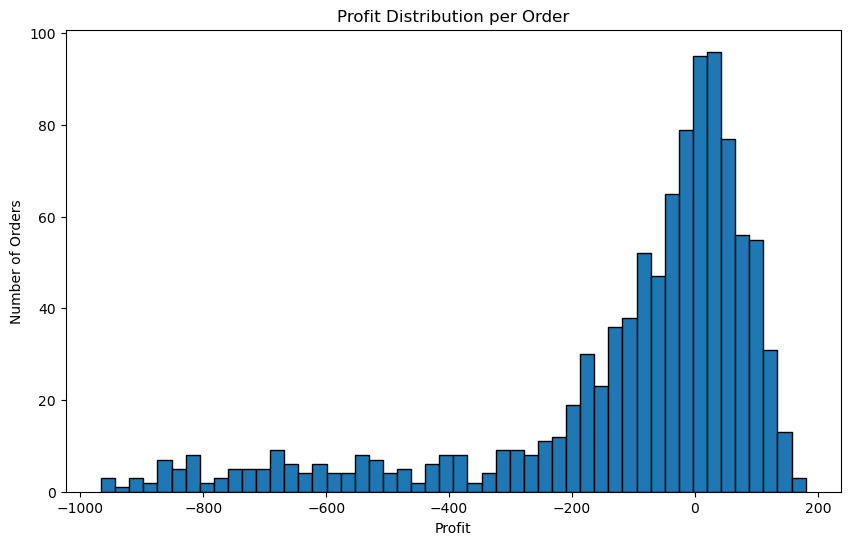

In [19]:
# ===============================
# STEP 9: Profit Distribution Analysis
# ===============================

# Plot histogram of profit per order
plt.figure(figsize=(10,6))

plt.hist(df["Profit"], bins=50, edgecolor="black")

plt.title("Profit Distribution per Order")

plt.xlabel("Profit")

plt.ylabel("Number of Orders")

plt.show()

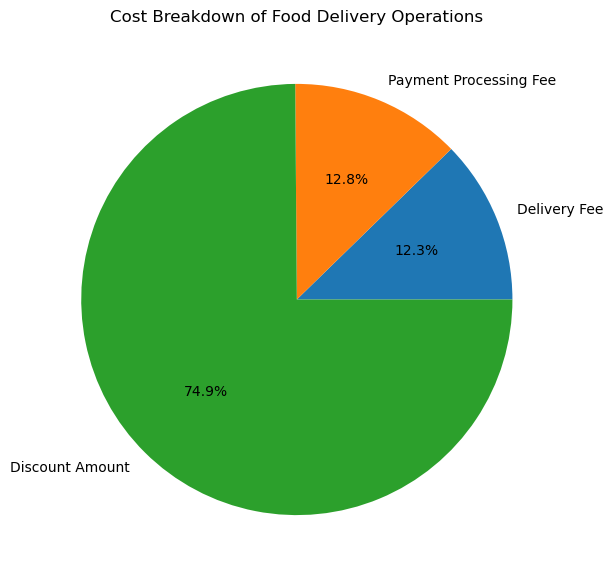

In [20]:
# ===============================
# STEP 10: Cost Breakdown Analysis
# ===============================

# Sum each cost component
costs = df[[
    "Delivery Fee",
    "Payment Processing Fee",
    "Discount Amount"
]].sum()

# Plot pie chart of cost components
plt.figure(figsize=(7,7))

plt.pie(costs, labels=costs.index, autopct="%1.1f%%")

plt.title("Cost Breakdown of Food Delivery Operations")

plt.show()

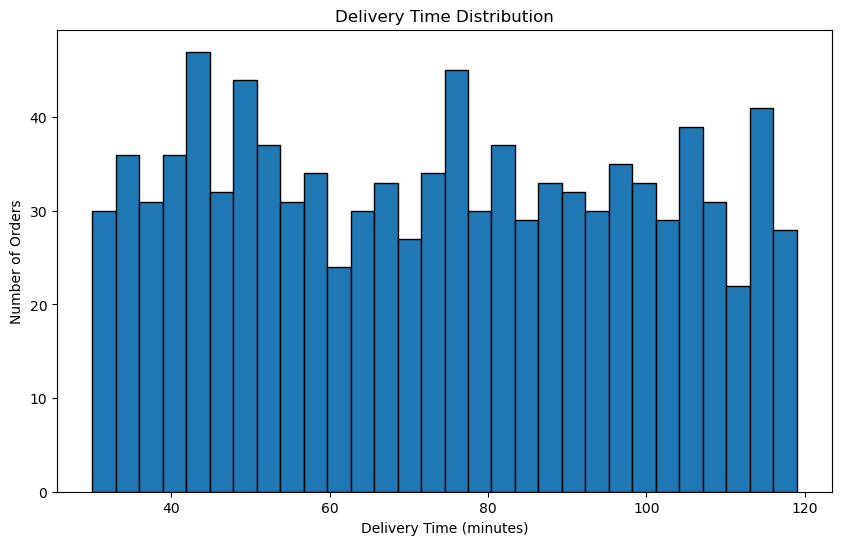

In [21]:
# ===============================
# STEP 11: Delivery Time Analysis
# ===============================

# Calculate delivery time in minutes
df["Delivery Time"] = (
    df["Delivery Date and Time"] -
    df["Order Date and Time"]
).dt.total_seconds() / 60

# Plot delivery time distribution
plt.figure(figsize=(10,6))

plt.hist(df["Delivery Time"], bins=30, edgecolor="black")

plt.title("Delivery Time Distribution")

plt.xlabel("Delivery Time (minutes)")

plt.ylabel("Number of Orders")

plt.show()

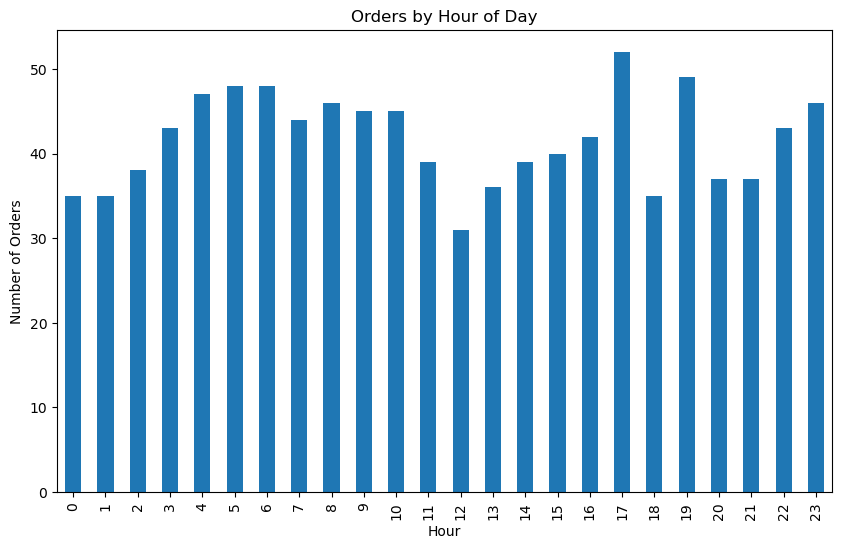

In [22]:
# ===============================
# STEP 12: Peak Order Hour Analysis
# ===============================

# Extract hour from order timestamp
df["Order Hour"] = df["Order Date and Time"].dt.hour

# Count number of orders per hour
orders_by_hour = df.groupby("Order Hour").size()

# Plot orders by hour
orders_by_hour.plot(kind="bar", figsize=(10,6))

plt.title("Orders by Hour of Day")

plt.xlabel("Hour")

plt.ylabel("Number of Orders")

plt.show()

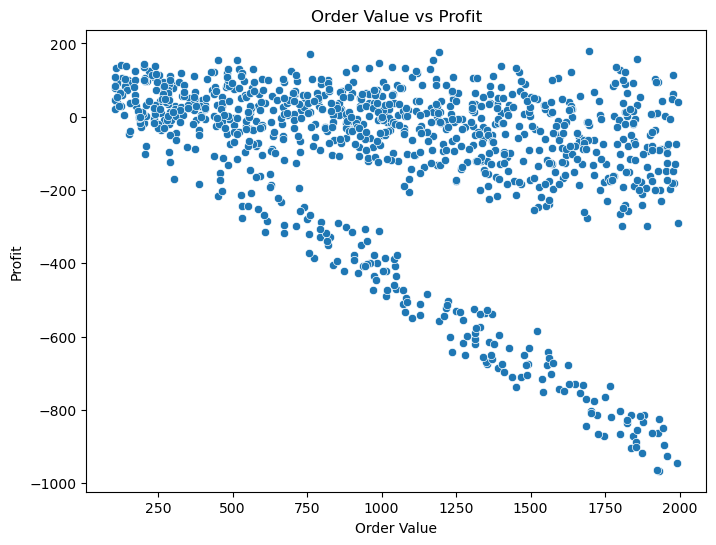

In [23]:
# ===============================
# STEP 13: Profit vs Order Value
# ===============================

# Scatter plot to see relationship between order value and profit
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Order Value"],
    y=df["Profit"]
)

plt.title("Order Value vs Profit")

plt.xlabel("Order Value")

plt.ylabel("Profit")

plt.show()